In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow_lattice as tfl

In [ ]:
# --- Step 1: Prepare data ---
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 1 = benign, 0 = malignant

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [3]:
# --- Step 2: Unconstrained baseline (standard Keras MLP) ---
baseline_model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
baseline_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
baseline_model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.15, verbose=0)

baseline_preds = (baseline_model.predict(X_test_scaled) > 0.5).astype(int).flatten()
print("=== Unconstrained Baseline ===")
print(classification_report(y_test, baseline_preds, target_names=data.target_names))

c:\Users\liamt\.pyenv\pyenv-win\versions\3.12.1\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
=== Unconstrained Baseline ===
              precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        43
      benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
# --- Step 3: Constrained model using TensorFlow Lattice ---
# Select a subset of features for the lattice model
selected_features = ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean smoothness', 'texture error']
feature_indices = [list(data.feature_names).index(f) for f in selected_features]

X_train_sub = X_train_scaled[:, feature_indices]
X_test_sub = X_test_scaled[:, feature_indices]

# Define feature configs with monotonicity constraints
feature_configs = [
    tfl.configs.FeatureConfig(
        name='worst_concave_points',
        lattice_size=4,
        monotonicity=-1,  # larger radius → less likely benign
        pwl_calibration_input_keypoints=np.linspace(0.0, 1.0, 10).tolist(),
    ),
    tfl.configs.FeatureConfig(
        name='worst_perimeter',
        lattice_size=4,
        monotonicity=-1,  # more concavity → less likely benign
        pwl_calibration_input_keypoints=np.linspace(0.0, 1.0, 10).tolist(),
    ),
    tfl.configs.FeatureConfig(
        name='mean_concave_points',
        lattice_size=4,
        monotonicity=-1,
        pwl_calibration_input_keypoints=np.linspace(0.0, 1.0, 10).tolist(),
    ),
    tfl.configs.FeatureConfig(
        name='worst_radius',
        lattice_size=4,
        monotonicity=-1,
        pwl_calibration_input_keypoints=np.linspace(0.0, 1.0, 10).tolist(),
    ),
    tfl.configs.FeatureConfig(
        name='mean_smoothness',
        lattice_size=4,
        monotonicity=0,   # no constraint — let the model learn freely
        pwl_calibration_input_keypoints=np.linspace(0.0, 1.0, 10).tolist(),
    ),
    tfl.configs.FeatureConfig(
        name='texture_error',
        lattice_size=4,
        monotonicity=0,   # no constraint
        pwl_calibration_input_keypoints=np.linspace(0.0, 1.0, 10).tolist(),
    ),
]

# Build a calibrated lattice model

model_config = tfl.configs.CalibratedLatticeConfig(
    feature_configs=feature_configs,
    output_min=0.0,
    output_max=1.0,
    output_calibration=False, 
    output_initialization=[0.0, 1.0], # <-- Add this line!
)

lattice_model = tfl.premade.CalibratedLattice(model_config)
lattice_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Prepare input as dict
def make_input_dict(X_array, feature_names):
    return {f"tfl_input_{name}": X_array[:, i].astype(np.float32) for i, name in enumerate(feature_names)}

feature_keys = ['worst_concave_points', 'worst_perimeter', 'mean_concave_points', 'worst_radius', 'mean_smoothness', 'texture_error']

train_dict = make_input_dict(X_train_sub, feature_keys)
test_dict = make_input_dict(X_test_sub, feature_keys)

lattice_model.fit(train_dict, y_train.astype(np.float32), epochs=100, batch_size=32, validation_split=0.15, verbose=0)

lattice_preds = (lattice_model.predict(test_dict) > 0.5).astype(int).flatten()
print("\n=== Monotonicity-Constrained Lattice Model ===")
print(classification_report(y_test, lattice_preds, target_names=data.target_names))



4/4 [==============================] - 0s 1ms/step

=== Monotonicity-Constrained Lattice Model ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



2/2 [==============================] - 0s 0s/step


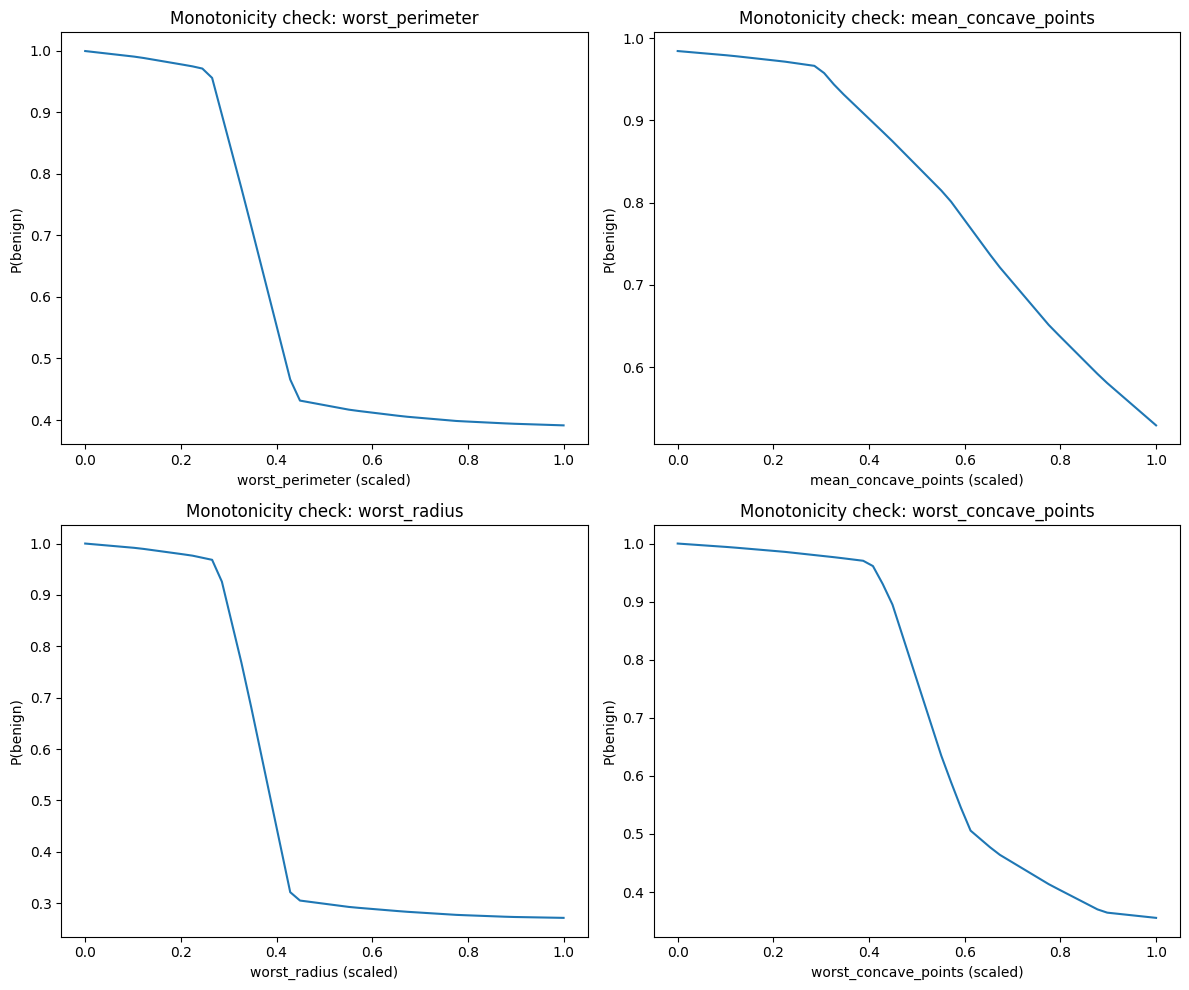

In [ ]:
# --- Step 4: Verify monotonicity actually holds ---
def monotonicity_check(model, feature_idx, feature_name, X_baseline, feature_keys):
    """Sweep one feature from 0 to 1 while holding others at median values."""
    medians = np.median(X_baseline, axis=0)
    sweep = np.linspace(0, 1, 50)
    inputs = np.tile(medians, (50, 1))
    inputs[:, feature_idx] = sweep
    input_dict = make_input_dict(inputs, feature_keys)
    preds = model.predict(input_dict).flatten()
    return sweep, preds

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
constrained_features = ['worst_perimeter', 'mean_concave_points', 'worst_radius', 'worst_concave_points']
for ax, feat in zip(axes.ravel(), constrained_features):
    idx = feature_keys.index(feat)
    sweep, preds = monotonicity_check(lattice_model, idx, feat, X_train_sub, feature_keys)
    ax.plot(sweep, preds)
    ax.set_xlabel(f'{feat} (scaled)')
    ax.set_ylabel('P(benign)')
    ax.set_title(f'Monotonicity check: {feat}')
plt.tight_layout()
plt.savefig('monotonicity_verification.png', dpi=150)

2/2 [==============================] - 0s 1ms/step


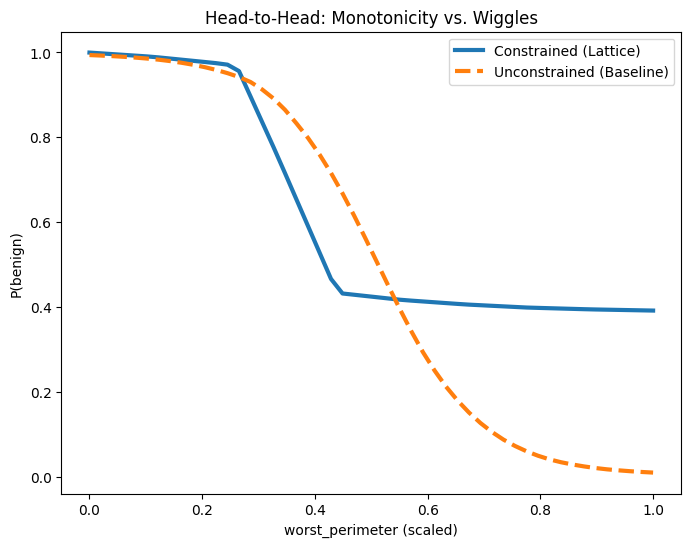

In [ ]:
# 1. Train a "fair fight" unconstrained baseline on the exact same 6 features
mini_baseline = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(6,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
mini_baseline.compile(optimizer='adam', loss='binary_crossentropy')
mini_baseline.fit(X_train_sub, y_train, epochs=100, batch_size=32, verbose=0)

# 2. Sweep the worst_perimeter feature
idx = feature_keys.index('worst_perimeter')

# Get Lattice predictions
sweep_lattice, preds_lattice = monotonicity_check(lattice_model, idx, 'worst_perimeter', X_train_sub, feature_keys)

# Get Baseline predictions
medians = np.median(X_train_sub, axis=0)
inputs_array = np.tile(medians, (50, 1))
inputs_array[:, idx] = sweep_lattice # sweep from 0 to 1
preds_baseline = mini_baseline.predict(inputs_array, verbose=0).flatten()

# 3. Plot them head-to-head!
plt.figure(figsize=(8, 6))
plt.plot(sweep_lattice, preds_lattice, label='Constrained (Lattice)', linewidth=3)
plt.plot(sweep_lattice, preds_baseline, label='Unconstrained (Baseline)', linewidth=3, linestyle='--')
plt.xlabel('worst_perimeter (scaled)')
plt.ylabel('P(benign)')
plt.title('Head-to-Head: Monotonicity vs. Wiggles')
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report

# 6 features: 
# ['worst_concave_points', 'worst_perimeter', 'mean_concave_points', 'worst_radius', 'mean_smoothness', 'texture_error']
# The first 4 are heavily correlated with malignancy (-1). The last 2 are noisy (0).
constraints = [-1, -1, -1, -1, 0, 0]

# Build and train the model in two lines of code
sklearn_model = HistGradientBoostingClassifier(monotonic_cst=constraints, random_state=42)
sklearn_model.fit(X_train_sub, y_train)

# Test it
sklearn_preds = sklearn_model.predict(X_test_sub)
print("=== Scikit-Learn Constrained Model ===")
print(classification_report(y_test, sklearn_preds, target_names=data.target_names))

=== Scikit-Learn Constrained Model ===
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        43
      benign       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

